In [1]:
import pandas as pd

df = pd.read_csv("../data/literacy.csv")
df.head()

,Year,State,Literacy,Primary_Enrollment,Primary_Schools,Schools_per_1000
0,2021-22,Andhra Pradesh,63.2,3802343,38430,10.106926
1,2021-22,Arunachal Pradesh,81.9,169096,1847,10.922789
2,2021-22,Assam,87.0,3706238,40482,10.922666
3,2021-22,Bihar,71.0,13728283,42505,3.096163
4,2021-22,Chhattisgarh,76.1,2656716,32723,12.317086


In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                34 non-null     str    
 1   State               34 non-null     str    
 2   Literacy            34 non-null     float64
 3   Primary_Enrollment  34 non-null     int64  
 4   Primary_Schools     34 non-null     int64  
 5   Schools_per_1000    34 non-null     float64
dtypes: float64(2), int64(2), str(2)
memory usage: 1.7 KB


,Literacy,Primary_Enrollment,Primary_Schools,Schools_per_1000
count,34.000000,3.400000e+01,34.000000,34.000000
mean,80.579412,3.571218e+06,22089.794118,7.670469
std,9.963685,4.938462e+06,28558.062653,4.473287
min,62.300000,5.294000e+03,16.000000,0.230233
25%,73.800000,1.721150e+05,1572.500000,4.623634
50%,79.150000,2.405288e+06,13470.000000,7.076639
75%,87.450000,4.822062e+06,34477.250000,10.718731
max,99.800000,2.412622e+07,138078.000000,19.965778


In [3]:
import numpy as np

df["Schools_per_1000"] = np.log1p(df["Schools_per_1000"])

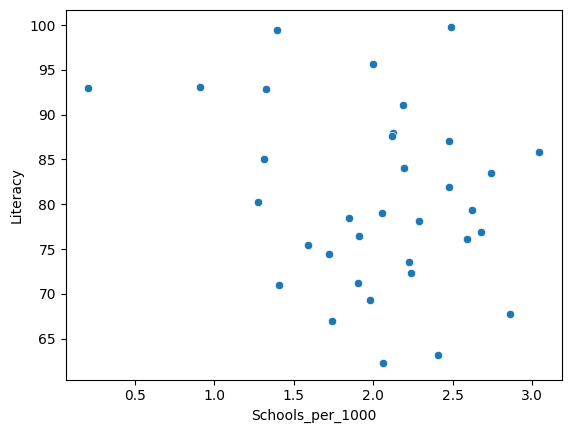

In [8]:

import matplotlib.pyplot as plt

sns.scatterplot(x="Schools_per_1000", y="Literacy", data=df)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Schools_per_1000"]]
y = df["Literacy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.5571437329332336


In [7]:
import pickle

with open("../model/model.pkl", "wb") as f:
    pickle.dump(model, f)

In [9]:
from sklearn.model_selection import train_test_split

X = df[["Schools_per_1000"]]
y = df["Literacy"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = model.predict(X_test)

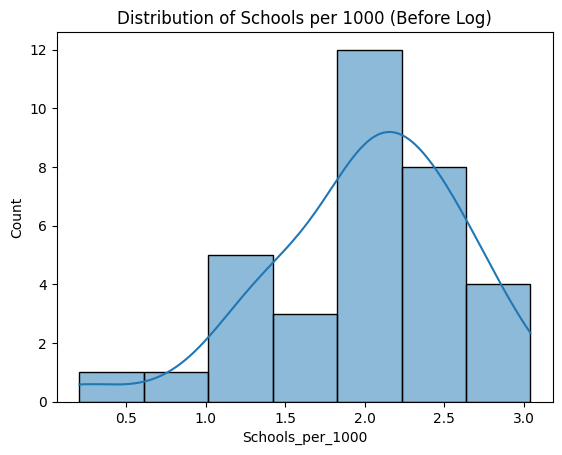

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Schools_per_1000"], kde=True)
plt.title("Distribution of Schools per 1000 (Before Log)")
plt.show()

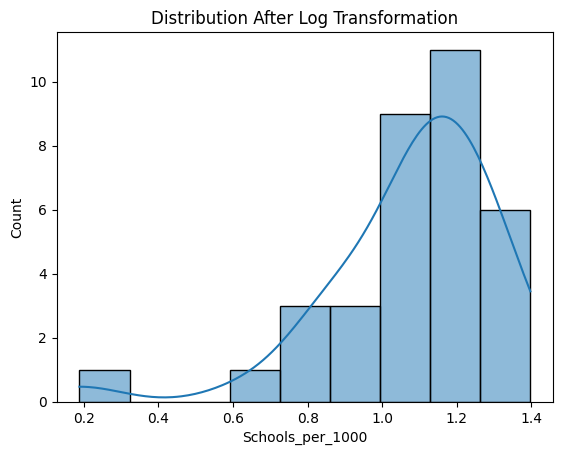

In [13]:
sns.histplot(np.log1p(df["Schools_per_1000"]), kde=True)
plt.title("Distribution After Log Transformation")
plt.show()

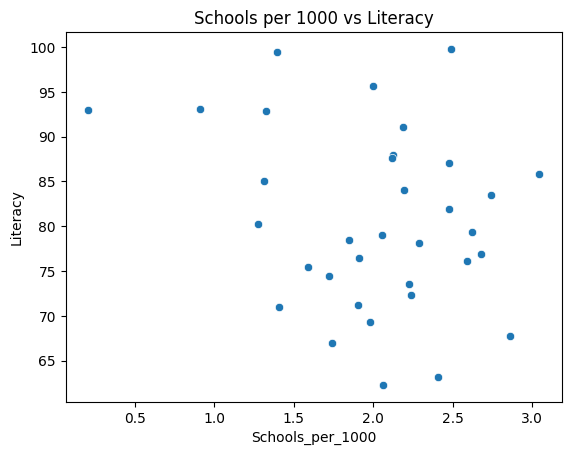

In [14]:
sns.scatterplot(x="Schools_per_1000", y="Literacy", data=df)
plt.title("Schools per 1000 vs Literacy")
plt.show()

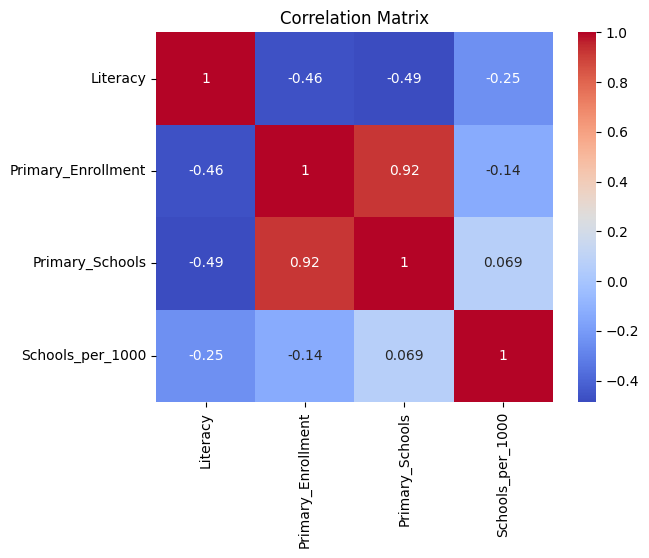

In [16]:
numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

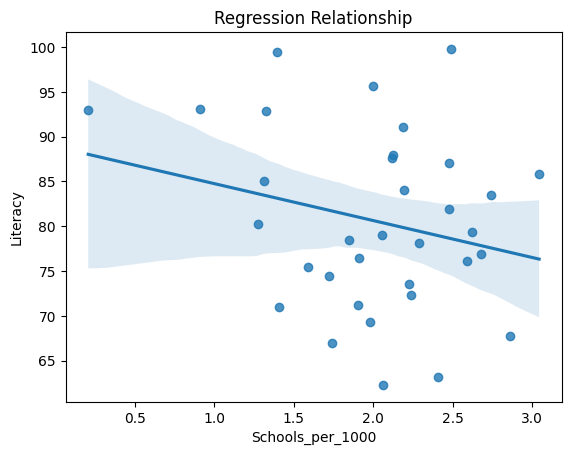

In [17]:
sns.regplot(x="Schools_per_1000", y="Literacy", data=df)
plt.title("Regression Relationship")
plt.show()